In [12]:
from pathlib import Path
import sys

from urllib.request import urlretrieve
import hashlib
import zipfile

import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_SEED = 20260911
PRE_OFFSET_SECONDS = 0.150
OPENING_THRESHOLD_DEG = 5.0

SELECTED_SWING = None

In [13]:
LANDMARKS_URL = (
    "https://github.com/drivelineresearch/openbiomechanics/releases/download/"
    "dataset-v1/hitting_landmarks.zip"
)
LANDMARKS_SHA256 = "9cc2bdc94f5f5a6c5d540f4abe459caae2c5164cd53f6a6fd23f4b2b7283bcb3"
METADATA_URL = (
    "https://raw.githubusercontent.com/drivelineresearch/openbiomechanics/"
    "dataset-v1/baseball_hitting/data/metadata.csv"
)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def locate_or_download_data():

    cwd = Path.cwd()
    candidate_roots = [cwd, cwd / "openbiomechanics"]

    for root in candidate_roots:
        landmarks = root / "baseball_hitting/data/full_sig/landmarks.csv"
        metadata = root / "baseball_hitting/data/metadata.csv"
        if landmarks.exists() and metadata.exists():
            return landmarks, metadata, "existing OBP repository data"

    cache = cwd / "obp_hinge_data"
    cache.mkdir(parents=True, exist_ok=True)
    landmarks = cache / "landmarks.csv"
    metadata = cache / "metadata.csv"
    archive = cache / "hitting_landmarks.zip"

    if not landmarks.exists():
        print("Downloading official OBP hitting landmarks (~66 MB)...")
        urlretrieve(LANDMARKS_URL, archive)
        actual_hash = sha256_file(archive)
        if actual_hash != LANDMARKS_SHA256:
            raise ValueError(
                "Checksum mismatch for hitting_landmarks.zip. "
                f"Expected {LANDMARKS_SHA256}, received {actual_hash}."
            )
        with zipfile.ZipFile(archive) as zf:
            if "landmarks.csv" not in zf.namelist():
                raise FileNotFoundError("The verified archive does not contain landmarks.csv.")
            zf.extract("landmarks.csv", cache)

    if not metadata.exists():
        print("Downloading official OBP hitting metadata...")
        urlretrieve(METADATA_URL, metadata)

    return landmarks, metadata, "downloaded official OBP release data"


PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd(), *Path.cwd().parents]
        if (path / "src" / "obp_utils.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate src/obp_utils.py. "
        "Open this notebook from inside the project repository."
    )

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from obp_utils import get_data_path


landmarks_path = get_data_path("hitting", "landmarks.csv")
metadata_path = get_data_path("hitting", "metadata.csv")
data_source = "local official OpenBiomechanics data"

print(f"Landmarks: {landmarks_path.relative_to(PROJECT_ROOT)}")
print(f"Metadata:  {metadata_path.relative_to(PROJECT_ROOT)}")
print(f"Source:    {data_source}")

Landmarks: data\raw\hitting\landmarks.csv
Metadata:  data\raw\hitting\metadata.csv
Source:    local official OpenBiomechanics data


In [14]:
LANDMARK_BASES = [
    "left_hip", "right_hip", "lsjc", "rsjc",
    "lkjc", "rkjc", "lajc", "rajc",
]
COORD_COLUMNS = [f"{name}_{axis}" for name in LANDMARK_BASES for axis in "xyz"]
EVENT_COLUMNS = ["fp_10_time", "fp_100_time", "contact_time"]
USE_COLUMNS = ["session_swing", "time", *COORD_COLUMNS, *EVENT_COLUMNS]

landmarks = pd.read_csv(
    landmarks_path,
    usecols=USE_COLUMNS,
    dtype={"session_swing": str},
)
metadata = pd.read_csv(metadata_path, dtype={"session_swing": str})

meta_columns = [
    "session_swing", "user", "hitter_side", "exit_velo_mph_x",
    "bat_speed_mph_max_x", "athlete_age", "highest_playing_level",
]
kinematics = landmarks.merge(
    metadata[meta_columns].drop_duplicates("session_swing"),
    on="session_swing",
    how="left",
    validate="many_to_one",
)

print(f"Rows: {len(kinematics):,}")
print(f"Swings in landmarks: {kinematics['session_swing'].nunique():,}")
print(f"Athletes in landmarks: {kinematics['user'].nunique():,}")
print(f"Approximate sampling interval: {kinematics.groupby('session_swing')['time'].diff().median():.4f} s")

Rows: 469,377
Swings in landmarks: 677
Athletes in landmarks: 98
Approximate sampling interval: 0.0028 s


In [15]:
def angle_between(a, b):

    denominator = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    cosine = np.einsum("ij,ij->i", a, b) / denominator
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))


hip_mid = np.column_stack([
    (kinematics[f"left_hip_{a}"] + kinematics[f"right_hip_{a}"]) / 2
    for a in "xyz"
])
shoulder_mid = np.column_stack([
    (kinematics[f"lsjc_{a}"] + kinematics[f"rsjc_{a}"]) / 2
    for a in "xyz"
])

is_right_handed = kinematics["hitter_side"].eq("R").to_numpy()
rear_hip = np.column_stack([
    np.where(
        is_right_handed,
        kinematics[f"right_hip_{a}"],
        kinematics[f"left_hip_{a}"],
    )
    for a in "xyz"
])
rear_knee = np.column_stack([
    np.where(
        is_right_handed,
        kinematics[f"rkjc_{a}"],
        kinematics[f"lkjc_{a}"],
    )
    for a in "xyz"
])

trunk_vector = shoulder_mid - hip_mid
rear_thigh_vector = rear_knee - rear_hip

kinematics["hinge_angle_xz_deg"] = angle_between(
    trunk_vector[:, [0, 2]], rear_thigh_vector[:, [0, 2]]
)
kinematics["hinge_angle_3d_deg"] = angle_between(trunk_vector, rear_thigh_vector)

if kinematics[["hinge_angle_xz_deg", "hinge_angle_3d_deg"]].isna().any().any():
    raise ValueError("At least one hinge angle is missing; inspect zero-length or missing vectors.")

kinematics[["hinge_angle_xz_deg", "hinge_angle_3d_deg"]].describe().round(2)

,hinge_angle_xz_deg,hinge_angle_3d_deg
count,"469,377.00","469,377.00"
mean,165.36,133.31
std,11.20,15.34
min,111.46,75.50
25%,157.92,122.39
50%,168.13,133.51
75%,174.53,144.70
max,180.00,177.07


In [16]:
def nearest_frame(group, target_time):
    idx = np.abs(group["time"].to_numpy() - target_time).argmin()
    return group.iloc[idx]


def extract_event_results(pre_offset_seconds=PRE_OFFSET_SECONDS):
    records = []
    for session_swing, group in kinematics.groupby("session_swing", sort=False):
        ffc_time = group["fp_10_time"].iloc[0]
        plant_time = group["fp_100_time"].iloc[0]
        if pd.isna(ffc_time) or pd.isna(plant_time):
            continue

        pre_time = ffc_time - pre_offset_seconds
        if pre_time < group["time"].min() or plant_time > group["time"].max():
            continue

        pre = nearest_frame(group, pre_time)
        ffc = nearest_frame(group, ffc_time)
        plant = nearest_frame(group, plant_time)

        records.append({
            "session_swing": session_swing,
            "user": pre["user"],
            "hitter_side": pre["hitter_side"],
            "pre_time": pre["time"],
            "ffc_time": ffc["time"],
            "plant_time": plant["time"],
            "pre_angle_deg": pre["hinge_angle_xz_deg"],
            "ffc_angle_deg": ffc["hinge_angle_xz_deg"],
            "plant_angle_deg": plant["hinge_angle_xz_deg"],
            "delta_pre_to_ffc_deg": (
                ffc["hinge_angle_xz_deg"] - pre["hinge_angle_xz_deg"]
            ),
            "delta_ffc_to_plant_deg": (
                plant["hinge_angle_xz_deg"] - ffc["hinge_angle_xz_deg"]
            ),
            "delta_pre_to_plant_deg": (
                plant["hinge_angle_xz_deg"] - pre["hinge_angle_xz_deg"]
            ),
            "pre_angle_3d_deg": pre["hinge_angle_3d_deg"],
            "plant_angle_3d_deg": plant["hinge_angle_3d_deg"],
            "delta_pre_to_plant_3d_deg": (
                plant["hinge_angle_3d_deg"] - pre["hinge_angle_3d_deg"]
            ),
            "exit_velo_mph": pre["exit_velo_mph_x"],
            "bat_speed_mph": pre["bat_speed_mph_max_x"],
        })

    result = pd.DataFrame(records)
    result["hinge_flag"] = np.select(
        [
            result["delta_pre_to_plant_deg"] > OPENING_THRESHOLD_DEG,
            result["delta_pre_to_plant_deg"] < -OPENING_THRESHOLD_DEG,
        ],
        ["Opened >5°", "Closed >5°"],
        default="Within ±5°",
    )
    return result


results = extract_event_results()
print(f"Complete swings: {len(results):,} of {kinematics['session_swing'].nunique():,}")
print(f"Athletes represented: {results['user'].nunique():,}")
display(results.head())

Complete swings: 650 of 677
Athletes represented: 98


,session_swing,user,hitter_side,pre_time,ffc_time,plant_time,pre_angle_deg,ffc_angle_deg,plant_angle_deg,delta_pre_to_ffc_deg,delta_ffc_to_plant_deg,delta_pre_to_plant_deg,pre_angle_3d_deg,plant_angle_3d_deg,delta_pre_to_plant_3d_deg,exit_velo_mph,bat_speed_mph,hinge_flag
0,103_1,4,R,1.42,1.57,1.59,162.01,159.50,161.94,-2.51,2.44,-0.07,126.10,124.65,-1.44,97.20,69.22,Within ±5°
1,103_2,4,R,1.35,1.50,1.52,165.57,160.60,163.94,-4.98,3.34,-1.64,126.98,124.58,-2.40,88.80,66.04,Within ±5°
2,103_3,4,R,1.35,1.50,1.52,164.81,160.25,164.54,-4.56,4.29,-0.27,126.89,124.82,-2.07,88.90,65.04,Within ±5°
3,103_4,4,R,1.16,1.31,1.34,165.36,159.84,162.86,-5.52,3.02,-2.50,133.66,128.63,-5.02,83.10,60.93,Within ±5°
4,103_5,4,R,1.44,1.59,1.62,163.52,157.53,161.09,-5.99,3.56,-2.43,132.28,130.68,-1.60,91.60,66.07,Within ±5°


In [17]:
PHASE_COLUMNS = ["pre_angle_deg", "ffc_angle_deg", "plant_angle_deg"]
DELTA_COLUMNS = [
    "delta_pre_to_ffc_deg", "delta_ffc_to_plant_deg", "delta_pre_to_plant_deg"
]

summary = results[PHASE_COLUMNS + DELTA_COLUMNS].agg(["count", "mean", "std", "median"]).T
display(summary.round(2))

flag_summary = (
    results["hinge_flag"]
    .value_counts()
    .rename_axis("classification")
    .to_frame("swings")
)
flag_summary["percent"] = 100 * flag_summary["swings"] / len(results)
display(flag_summary.round(1))


def athlete_bootstrap_mean_ci(data, value_col, n_boot=5000, seed=RANDOM_SEED):
    athlete_means = data.groupby("user")[value_col].mean().dropna().to_numpy()
    rng = np.random.default_rng(seed)
    draws = rng.choice(
        athlete_means,
        size=(n_boot, len(athlete_means)),
        replace=True,
    ).mean(axis=1)
    return (
        athlete_means.mean(),
        np.quantile(draws, 0.025),
        np.quantile(draws, 0.975),
    )


mean_delta, ci_low, ci_high = athlete_bootstrap_mean_ci(
    results, "delta_pre_to_plant_deg"
)
print(
    "Athlete-weighted mean Δ (pre → plant): "
    f"{mean_delta:.2f}° (athlete-bootstrap 95% CI {ci_low:.2f}° to {ci_high:.2f}°)"
)

,count,mean,std,median
pre_angle_deg,650.00,157.75,10.44,156.91
ffc_angle_deg,650.00,155.53,10.11,154.63
plant_angle_deg,650.00,162.67,9.58,162.39
delta_pre_to_ffc_deg,650.00,-2.23,10.40,-3.13
delta_ffc_to_plant_deg,650.00,7.14,7.34,7.11
delta_pre_to_plant_deg,650.00,4.91,12.20,4.40


,swings,percent
classification,,
Opened >5°,312,48.00
Within ±5°,203,31.20
Closed >5°,135,20.80


Athlete-weighted mean Δ (pre → plant): 4.68° (athlete-bootstrap 95% CI 2.46° to 6.91°)


In [18]:
sensitivity_records = []
for offset in [0.100, 0.150, 0.200, 0.250]:
    temp = extract_event_results(pre_offset_seconds=offset)
    for event_name, delta_col in [
        ("Front-foot contact", "delta_pre_to_ffc_deg"),
        ("Foot plant", "delta_pre_to_plant_deg"),
    ]:
        sensitivity_records.append({
            "pre_offset_ms": int(offset * 1000),
            "post_event": event_name,
            "swings": len(temp),
            "athletes": temp["user"].nunique(),
            "mean_delta_deg": temp[delta_col].mean(),
            "median_delta_deg": temp[delta_col].median(),
            "sd_delta_deg": temp[delta_col].std(),
            "opened_gt_5_pct": 100 * (temp[delta_col] > OPENING_THRESHOLD_DEG).mean(),
        })

sensitivity = pd.DataFrame(sensitivity_records)
display(sensitivity.round(2))

,pre_offset_ms,post_event,swings,athletes,mean_delta_deg,median_delta_deg,sd_delta_deg,opened_gt_5_pct
0,100,Front-foot contact,650,98,1.10,0.34,9.30,26.77
1,100,Foot plant,650,98,8.24,7.56,11.80,59.08
2,150,Front-foot contact,650,98,-2.23,-3.13,10.40,22.15
3,150,Foot plant,650,98,4.91,4.40,12.20,48.00
4,200,Front-foot contact,650,98,-5.91,-6.27,10.50,14.00
5,200,Foot plant,650,98,1.24,0.76,11.93,37.38
6,250,Front-foot contact,650,98,-9.17,-9.30,10.47,8.77
7,250,Foot plant,650,98,-2.03,-2.45,11.52,27.23


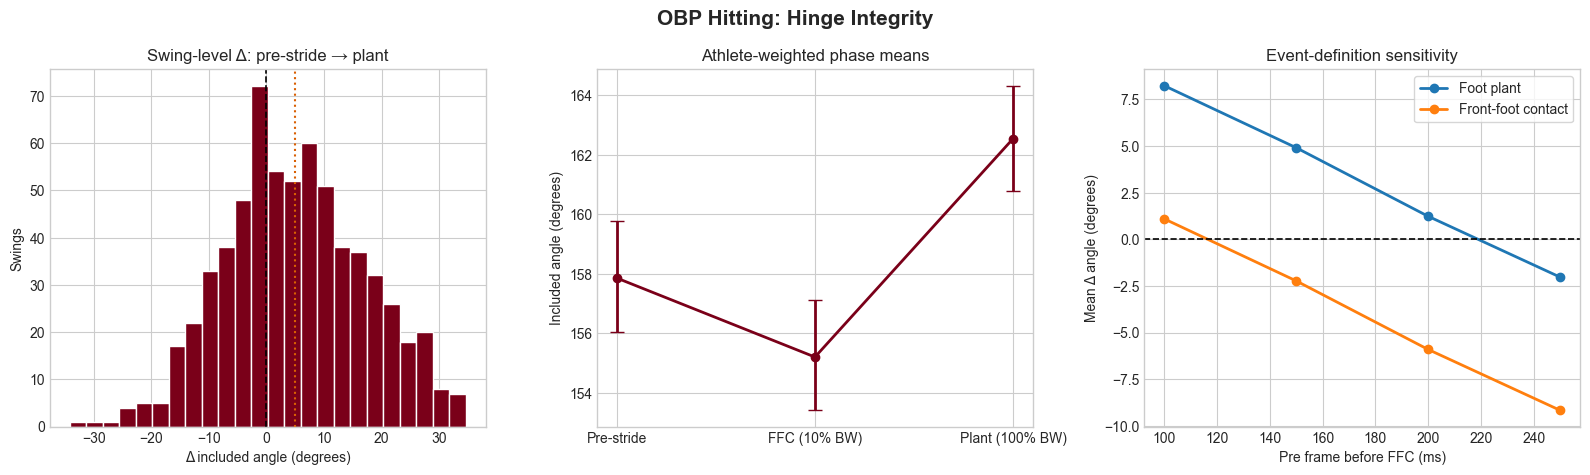

In [19]:
athlete_phase = results.groupby("user")[PHASE_COLUMNS].mean()
phase_labels = ["Pre-stride", "FFC (10% BW)", "Plant (100% BW)"]
phase_means, phase_lows, phase_highs = [], [], []
for column in PHASE_COLUMNS:
    mean, low, high = athlete_bootstrap_mean_ci(results, column)
    phase_means.append(mean)
    phase_lows.append(low)
    phase_highs.append(high)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].hist(
    results["delta_pre_to_plant_deg"],
    bins=24,
    color="#7A0019",
    edgecolor="white",
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[0].axvline(OPENING_THRESHOLD_DEG, color="#D95F02", linestyle=":", linewidth=1.5)
axes[0].set_title("Swing-level Δ: pre-stride → plant")
axes[0].set_xlabel("Δ included angle (degrees)")
axes[0].set_ylabel("Swings")

x = np.arange(3)
lower_error = np.array(phase_means) - np.array(phase_lows)
upper_error = np.array(phase_highs) - np.array(phase_means)
axes[1].errorbar(
    x,
    phase_means,
    yerr=np.vstack([lower_error, upper_error]),
    marker="o",
    color="#7A0019",
    capsize=5,
    linewidth=2,
)
axes[1].set_xticks(x, phase_labels)
axes[1].set_title("Athlete-weighted phase means")
axes[1].set_ylabel("Included angle (degrees)")

for event_name, event_group in sensitivity.groupby("post_event"):
    axes[2].plot(
        event_group["pre_offset_ms"],
        event_group["mean_delta_deg"],
        marker="o",
        linewidth=2,
        label=event_name,
    )
axes[2].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[2].set_title("Event-definition sensitivity")
axes[2].set_xlabel("Pre frame before FFC (ms)")
axes[2].set_ylabel("Mean Δ angle (degrees)")
axes[2].legend(frameon=True)

fig.suptitle("OBP Hitting: Hinge Integrity", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

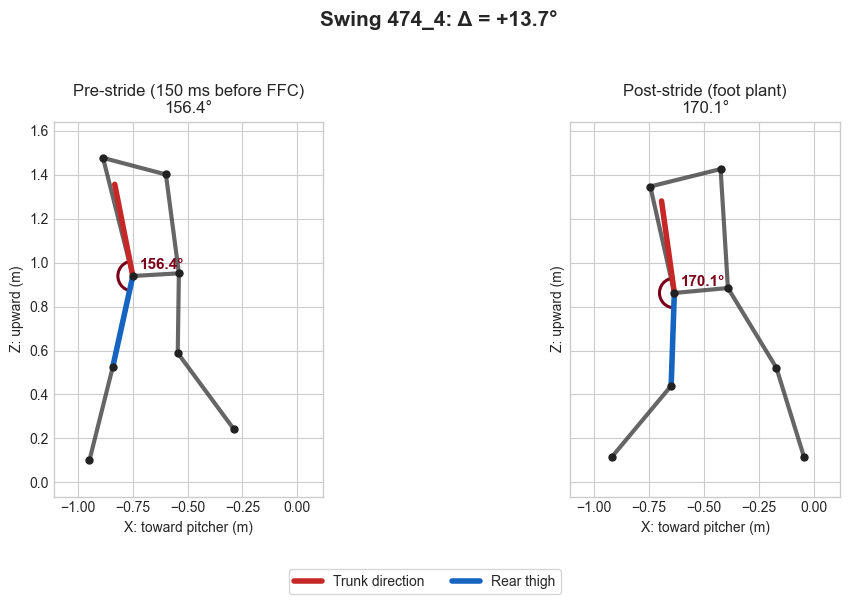

In [20]:
def row_at_time(session_swing, event_time):
    group = kinematics[kinematics["session_swing"].eq(str(session_swing))]
    if group.empty:
        raise KeyError(f"session_swing {session_swing!r} was not found.")
    return nearest_frame(group, event_time)


def xz(row, landmark):
    return np.array([row[f"{landmark}_x"], row[f"{landmark}_z"]], dtype=float)


def draw_small_angle_arc(ax, center, vector_a, vector_b, radius, color="#7A0019"):
    angle_a = np.degrees(np.arctan2(vector_a[1], vector_a[0]))
    angle_b = np.degrees(np.arctan2(vector_b[1], vector_b[0]))
    signed_difference = (angle_b - angle_a + 180) % 360 - 180
    endpoint = angle_a + signed_difference
    arc = Arc(
        center,
        2 * radius,
        2 * radius,
        theta1=min(angle_a, endpoint),
        theta2=max(angle_a, endpoint),
        color=color,
        linewidth=2.2,
    )
    ax.add_patch(arc)


def draw_freeze_frame(ax, row, title, common_limits):
    points = {name: xz(row, name) for name in LANDMARK_BASES}
    hip_midpoint = (points["left_hip"] + points["right_hip"]) / 2
    shoulder_midpoint = (points["lsjc"] + points["rsjc"]) / 2

    if row["hitter_side"] == "R":
        rear_hip_point, rear_knee_point = points["right_hip"], points["rkjc"]
    else:
        rear_hip_point, rear_knee_point = points["left_hip"], points["lkjc"]

    connections = [
        ("left_hip", "right_hip"),
        ("lsjc", "rsjc"),
        ("left_hip", "lsjc"),
        ("right_hip", "rsjc"),
        ("left_hip", "lkjc"),
        ("lkjc", "lajc"),
        ("right_hip", "rkjc"),
        ("rkjc", "rajc"),
    ]
    for start, end in connections:
        pair = np.vstack([points[start], points[end]])
        ax.plot(pair[:, 0], pair[:, 1], color="#333333", linewidth=3, alpha=0.75)

    for point in points.values():
        ax.scatter(*point, color="#222222", s=25, zorder=3)

    trunk_direction = shoulder_midpoint - hip_midpoint
    thigh_direction = rear_knee_point - rear_hip_point
    ray_length = np.linalg.norm(thigh_direction)
    trunk_ray = trunk_direction / np.linalg.norm(trunk_direction) * ray_length

    ax.plot(
        [rear_hip_point[0], rear_hip_point[0] + trunk_ray[0]],
        [rear_hip_point[1], rear_hip_point[1] + trunk_ray[1]],
        color="#C62828",
        linewidth=4,
        label="Trunk direction",
    )
    ax.plot(
        [rear_hip_point[0], rear_knee_point[0]],
        [rear_hip_point[1], rear_knee_point[1]],
        color="#1565C0",
        linewidth=4,
        label="Rear thigh",
    )

    radius = 0.16 * ray_length
    draw_small_angle_arc(ax, rear_hip_point, trunk_ray, thigh_direction, radius)
    ax.text(
        rear_hip_point[0] + 0.03,
        rear_hip_point[1] + 0.03,
        f"{row['hinge_angle_xz_deg']:.1f}°",
        color="#7A0019",
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlim(common_limits[0])
    ax.set_ylim(common_limits[1])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("X: toward pitcher (m)")
    ax.set_ylabel("Z: upward (m)")


if SELECTED_SWING is None:
    target_delta = results["delta_pre_to_plant_deg"].quantile(0.75)
    selection_index = (
        results["delta_pre_to_plant_deg"] - target_delta
    ).abs().idxmin()
    selected_swing = results.loc[selection_index, "session_swing"]
else:
    selected_swing = str(SELECTED_SWING)

selected_result = results.loc[
    results["session_swing"].eq(selected_swing)
].iloc[0]
pre_row = row_at_time(selected_swing, selected_result["pre_time"])
plant_row = row_at_time(selected_swing, selected_result["plant_time"])

plot_points = []
for row in [pre_row, plant_row]:
    for landmark in LANDMARK_BASES:
        plot_points.append(xz(row, landmark))
plot_points = np.vstack(plot_points)
x_margin = 0.18 * (plot_points[:, 0].max() - plot_points[:, 0].min())
z_margin = 0.12 * (plot_points[:, 1].max() - plot_points[:, 1].min())
common_limits = (
    (plot_points[:, 0].min() - x_margin, plot_points[:, 0].max() + x_margin),
    (plot_points[:, 1].min() - z_margin, plot_points[:, 1].max() + z_margin),
)

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharex=True, sharey=True)
draw_freeze_frame(
    axes[0],
    pre_row,
    f"Pre-stride ({PRE_OFFSET_SECONDS * 1000:.0f} ms before FFC)\n"
    f"{pre_row['hinge_angle_xz_deg']:.1f}°",
    common_limits,
)
draw_freeze_frame(
    axes[1],
    plant_row,
    f"Post-stride (foot plant)\n{plant_row['hinge_angle_xz_deg']:.1f}°",
    common_limits,
)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True)
fig.suptitle(
    f"Swing {selected_swing}: Δ = {selected_result['delta_pre_to_plant_deg']:+.1f}°",
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0.08, 1, 0.94))
plt.show()

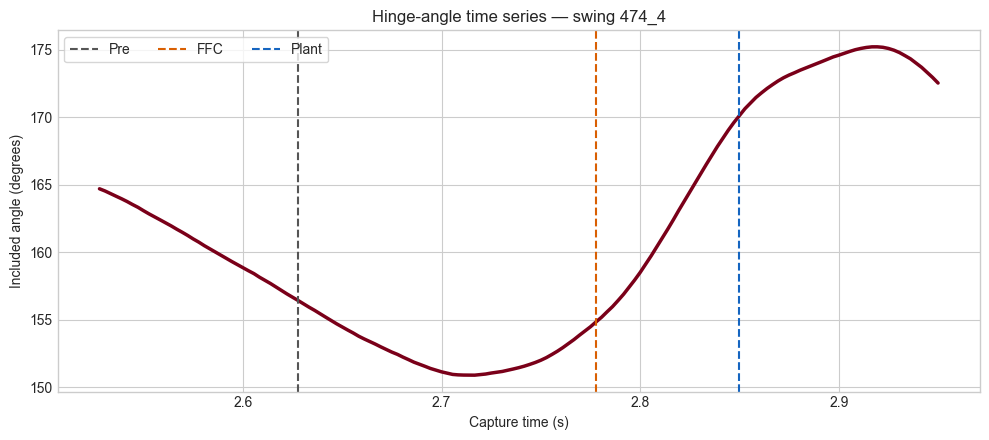

In [21]:
selected_series = kinematics[
    kinematics["session_swing"].eq(selected_swing)
].copy()
window = selected_series[
    selected_series["time"].between(
        selected_result["pre_time"] - 0.10,
        selected_result["plant_time"] + 0.10,
    )
]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(
    window["time"],
    window["hinge_angle_xz_deg"],
    color="#7A0019",
    linewidth=2.5,
)
for time_value, label, color in [
    (selected_result["pre_time"], "Pre", "#555555"),
    (selected_result["ffc_time"], "FFC", "#D95F02"),
    (selected_result["plant_time"], "Plant", "#1565C0"),
]:
    ax.axvline(time_value, color=color, linestyle="--", linewidth=1.5, label=label)
ax.set_title(f"Hinge-angle time series — swing {selected_swing}")
ax.set_xlabel("Capture time (s)")
ax.set_ylabel("Included angle (degrees)")
ax.legend(ncol=3, frameon=True)
fig.tight_layout()
plt.show()

,mean_delta_deg,mean_exit_velo_mph,mean_bat_speed_mph
mean_delta_deg,1.00,0.25,0.19
mean_exit_velo_mph,0.25,1.00,0.81
mean_bat_speed_mph,0.19,0.81,1.00


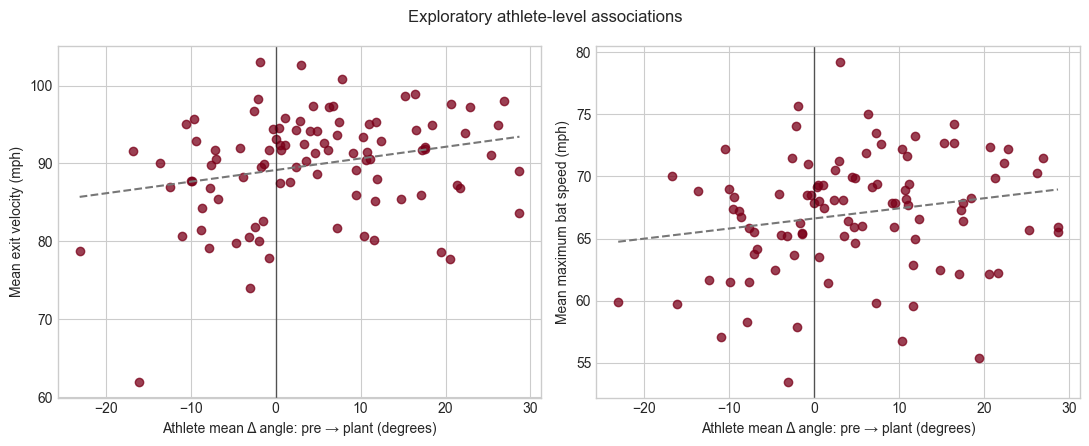

In [22]:
athlete_results = (
    results.groupby("user")
    .agg(
        swings=("session_swing", "size"),
        mean_delta_deg=("delta_pre_to_plant_deg", "mean"),
        mean_pre_angle_deg=("pre_angle_deg", "mean"),
        mean_plant_angle_deg=("plant_angle_deg", "mean"),
        mean_exit_velo_mph=("exit_velo_mph", "mean"),
        mean_bat_speed_mph=("bat_speed_mph", "mean"),
    )
    .reset_index()
)

correlations = athlete_results[
    ["mean_delta_deg", "mean_exit_velo_mph", "mean_bat_speed_mph"]
].corr()
display(correlations.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, outcome, label in [
    (axes[0], "mean_exit_velo_mph", "Mean exit velocity (mph)"),
    (axes[1], "mean_bat_speed_mph", "Mean maximum bat speed (mph)"),
]:
    valid = athlete_results[["mean_delta_deg", outcome]].dropna()
    ax.scatter(valid["mean_delta_deg"], valid[outcome], color="#7A0019", alpha=0.75)
    if len(valid) >= 2:
        slope, intercept = np.polyfit(valid["mean_delta_deg"], valid[outcome], 1)
        line_x = np.linspace(valid["mean_delta_deg"].min(), valid["mean_delta_deg"].max(), 100)
        ax.plot(line_x, slope * line_x + intercept, color="#777777", linestyle="--")
    ax.axvline(0, color="black", linewidth=1, alpha=0.6)
    ax.set_xlabel("Athlete mean Δ angle: pre → plant (degrees)")
    ax.set_ylabel(label)
fig.suptitle("Exploratory athlete-level associations")
fig.tight_layout()
plt.show()